# MNIST手写数字识别；
MNIST数据集是AI界的“Hello World”数据集，它包含60000张训练用到手写数字图片和10000张测试用到手写数字图片。

这个项目使用卷积神经网络（CNN）来识别手写数字。

这个项目的代码写在同一个Jupyter Notebook中，直接点击[全部运行]即可。

In [37]:
import torch;
import torch.nn as nn;
from torch.utils.data import DataLoader;
import torchvision;
import torchvision.transforms as transforms;
import numpy as np;
import matplotlib.pyplot as plt;
import torch.optim as optim;
import time;

In [38]:
# 设置训练时的批次大小(依次传入模型的数据数量)。
batch_size = 1024*2;

# 设置Matplotlib中文字体支持。
plt.rcParams['font.sans-serif'] = ['SimHei'];
plt.rcParams['axes.unicode_minus'] = False;

# 检查是否有可用的GPU。
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu');
print(f"使用设备: {device} ！");

使用设备: cuda ！


## 数据处理：

In [39]:
# 定义数据预处理的变换操作，将图片转换为PyTorch能接受的张量格式。
transform = transforms.Compose([
    # 将图片转换为PyTorch张量格式。
    transforms.ToTensor(),
    # 对数据进行标准化处理，均值为0.1307，标准差为0.3081（MNIST数据集的经验值）。
    transforms.Normalize((0.1307,), (0.3081,))
]);

### 划分训练集和测试集；

In [40]:
# 下载并加载MNIST 训练数据集。
train_dataset = torchvision.datasets.MNIST(
    root='./data', # 存放数据的位置。
    train=True,    # 载入训练集数据。
    download=True, # 下载数据集（如果不存在）。
    # 应用前面定义的预处理变换。
    transform=transform
);

# 下载并加载MNIST 测试数据集，和上面的代码差不多。
test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False, # 载入测试集数据。
    download=True,
    transform=transform
);

### 数据生成器：

In [41]:
# 创建训练数据生成器。
train_loader = DataLoader(
    train_dataset,          # 训练集数据集。
    batch_size=batch_size,  # 每个批次的样本数量。
    shuffle=True,           # 每个epoch随机打乱样本顺序。
    num_workers=4,          # Kaggle環境可以設置為4。
    pin_memory=True,        # 加速GPU數據傳輸。
    persistent_workers=True  # 保持數據加載進程。
);

# 创建测试数据生成器，和上面的训练数据生成器基本相同。
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
);


# for i,data in enumerate(train_loader):
#     x,y = data;
#     print(i);
#     print(x.shape); #torch.Size([2048, 1, 28, 28]) ————> (批次大小, 通道数, 高度, 宽度)
#     print(y.shape); #torch.Size([2048]) ————> 标签数量。
#     print(y[:10]);
#     break;

# print(len(train_loader));
# print(len(test_loader));

### 查看数据集:

训练集样本数量: 60000 ！
测试集样本数量: 10000 ！
图片尺寸: torch.Size([1, 28, 28]) ！
类别数量: 10 ！


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
/tmp/ipykernel_55/329401581.py:22: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout();
/tmp/ipykernel_55/329401581.py:22: UserWarning: Glyph 31614 (\N{CJK UNIFIED IDEOGRAPH-7B7E}) missing from font(s) DejaVu Sans.
  plt.tight_layout();
findfont: Generic family 'sans-serif' not found because none of th

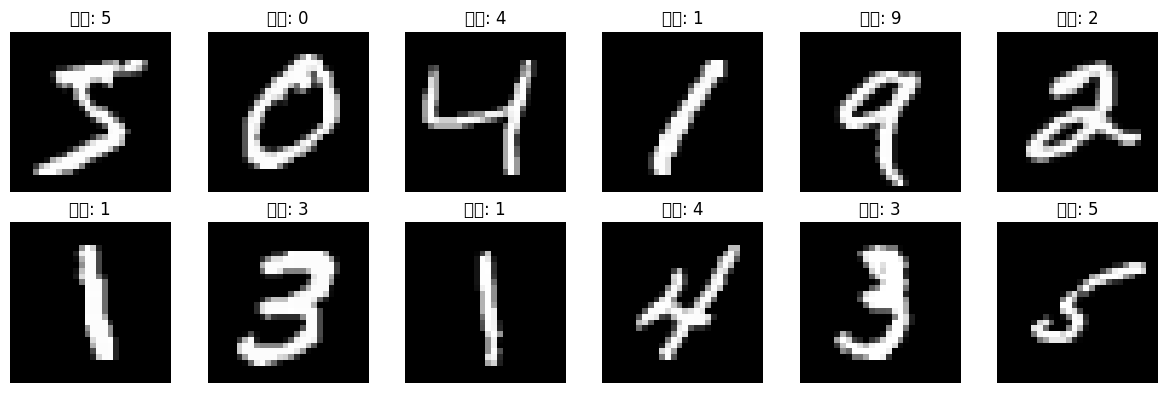

In [42]:
print(f"训练集样本数量: {len(train_dataset)} ！");
print(f"测试集样本数量: {len(test_dataset)} ！");
print(f"图片尺寸: {train_dataset[0][0].shape} ！");
print(f"类别数量: {len(train_dataset.classes)} ！");

plt.figure(figsize=(12, 4));

for i in range(12):
    # 创建子图，2行6列，当前是第i+1个。
    plt.subplot(2, 6, i + 1);
    # 获取第i张图片和标签。
    img, label = train_dataset[i];

    img = img.squeeze().numpy(); #将张量转换为numpy数组并去掉通道维度，方便显示。
    
    plt.imshow(img, cmap='gray');
    
    plt.title(f'标签: {label}');
    
    plt.axis('off');

plt.tight_layout();
plt.show();

## 模型：

In [43]:
# 定义卷积神经网络模型类。
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__();
        # 第一层 卷积层：
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1); # 输入1通道（灰度图），输出32通道，卷积核大小3x3。
        # 第一个批归一化层，对32个通道进行归一化。
        self.bn1 = nn.BatchNorm2d(32);
        # ReLU激活函数，引入非线性。
        self.relu1 = nn.ReLU();
        # 第一个最大池化层，池化核大小2x2，步长2。
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2);
        
        # 第二个卷积层：输入32通道，输出64通道。
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1);
        self.bn2 = nn.BatchNorm2d(64);
        self.relu2 = nn.ReLU();
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2);
        
        # 第三个卷积层：输入64通道，输出128通道。
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1);
        self.bn3 = nn.BatchNorm2d(128);
        self.relu3 = nn.ReLU();
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2);
        
        self.dropout = nn.Dropout(0.3);
        self.fc1 = nn.Linear(128*3*3, 256);# 第一个全连接层：输入128*3*3=1152，输出256。
        self.relu4 = nn.ReLU();
        self.dropout2 = nn.Dropout(0.3);
        self.fc2 = nn.Linear(256, 10);# 第二个全连接层：输入256，输出10（对应0-9十个数字类别）。
    
    # 前向传播函数，定义数据流向。
    def forward(self, x): 
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))));# 第一层卷积+批归一化+激活+池化。
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))));
        x = self.pool3(self.relu3(self.bn3(self.conv3(x))));

        # 将特征图展平为一维向量。
        x = x.view(x.size(0), -1);

        x = self.dropout(x);
        x = self.relu4(self.fc1(x));
        x = self.dropout2(x);
        x = self.fc2(x);

        return x;

In [44]:
# 创建模型实例。
model = CNN();
print(model);

# 多GPU支持。
if torch.cuda.device_count() > 1:
    print(f"使用 {torch.cuda.device_count()} 个GPU进行训练 ！");
    model = nn.DataParallel(model);
# 将模型移动到指定设备（GPU或CPU）。
model = model.to(device);

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=1152, out_features=256, bias=True)
  (relu4): ReLU()
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc2): Linear(

## 训练：

In [45]:
# 定义训练函数。
def train(model, train_loader, criterion, optimizer, device, scaler=None):
    model.train();
    running_loss = 0.0;
    correct = 0;
    total = 0;
    
    for batch_idx, (data, target) in enumerate(train_loader): # 遍历训练集数据生成器。
        data, target = data.to(device), target.to(device);
        
        optimizer.zero_grad();
        
        if scaler is not None:
            with torch.cuda.amp.autocast():
                output = model(data);
                loss = criterion(output, target);
            scaler.scale(loss).backward();
            scaler.step(optimizer);
            scaler.update();
        else:
            output = model(data);
            loss = criterion(output, target); # criterion = nn.CrossEntropyLoss();
            loss.backward(); # 反向传播，计算梯度。
            optimizer.step();# 更新参数。
        
        running_loss += loss.item();
        _, predicted = output.max(1);
        total += target.size(0);
        correct += predicted.eq(target).sum().item();
    
    avg_loss = running_loss / len(train_loader);
    accuracy = 100. * correct / total;
    return avg_loss, accuracy;

In [46]:
# 定义测试函数。
def test(model, test_loader, criterion, device):
    # 将模型设置为评估模式。
    model.eval();

    running_loss = 0.0; #累计损失。
    correct = 0; #正确预测数量。 
    total = 0; #总样本数量。
    
    # 不计算梯度，节省内存和计算资源。
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device);
            
            output = model(data);
        
            loss = criterion(output, target);

            running_loss += loss.item(); # 累加损失值。
            # 获取预测结果。
            _, predicted = output.max(1);

            total += target.size(0); # 累加总样本数。
            correct += predicted.eq(target).sum().item(); # 累加正确预测数。
    
    # 计算平均损失。
    avg_loss = running_loss / len(test_loader);
    # 计算准确率。
    accuracy = 100. * correct / total;
    # 返回平均损失和准确率。
    return avg_loss, accuracy;

### 开始训练：

In [47]:
%%time

# 设置训练轮数。
num_epochs = 50;

# 创建列表用于存储训练历史。
train_losses = [];
train_accuracies = [];
test_losses = [];
test_accuracies = [];

best_accuracy = 0.0;

# 损失函数（交叉熵损失）。
criterion = nn.CrossEntropyLoss();
# 优化器（Adam优化器，学习率0.001）。
optimizer = optim.Adam(model.parameters(), lr=0.001);
# 学习率调度器（每10个epoch将学习率乘以0.1）。
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1);

# 混合精度训练scaler。
scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else None;

# 开始训练循环。
for epoch in range(num_epochs):
    epoch_start = time.time();# 計時。
    
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, device, scaler);
    test_loss, test_acc = test(model, test_loader, criterion, device);
    
    scheduler.step();
    
    train_losses.append(train_loss);
    train_accuracies.append(train_acc);
    test_losses.append(test_loss);
    test_accuracies.append(test_acc);
    
    epoch_time = time.time() - epoch_start;
    
    print(f"轮次： [{epoch+1}/{num_epochs}] "
          f"训练损失： {train_loss:.4f}, 训练准确率： {train_acc:.2f}% "
          f"测试损失： {test_loss:.4f}, 测试准确率： {test_acc:.2f}% "
          f"耗时: {epoch_time:.2f}s ！");
    
    # 保存最佳模型。
    if test_acc > best_accuracy:
        best_accuracy = test_acc;
        if isinstance(model, nn.DataParallel):
            torch.save(model.module.state_dict(), 'mnist_cnn_best.pth');
        else:
            torch.save(model.state_dict(), 'mnist_cnn_best.pth');
        print(f"✅最佳模型已保存 (准确率: {best_accuracy:.2f}%) ！");

/tmp/ipykernel_55/3779991258.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


轮次： [1/50] 训练损失： 0.5928, 训练准确率： 81.79% 测试损失： 0.0999, 测试准确率： 96.99% 耗时: 7.24s ！
✅最佳模型已保存 (准确率: 96.99%) ！
轮次： [2/50] 训练损失： 0.0967, 训练准确率： 97.10% 测试损失： 0.0454, 测试准确率： 98.53% 耗时: 6.04s ！
✅最佳模型已保存 (准确率: 98.53%) ！
轮次： [3/50] 训练损失： 0.0653, 训练准确率： 98.05% 测试损失： 0.0529, 测试准确率： 98.41% 耗时: 6.20s ！
轮次： [4/50] 训练损失： 0.0516, 训练准确率： 98.42% 测试损失： 0.0375, 测试准确率： 98.71% 耗时: 5.98s ！
✅最佳模型已保存 (准确率: 98.71%) ！
轮次： [5/50] 训练损失： 0.0428, 训练准确率： 98.68% 测试损失： 0.0270, 测试准确率： 99.15% 耗时: 6.15s ！
✅最佳模型已保存 (准确率: 99.15%) ！
轮次： [6/50] 训练损失： 0.0376, 训练准确率： 98.86% 测试损失： 0.0308, 测试准确率： 98.96% 耗时: 6.13s ！
轮次： [7/50] 训练损失： 0.0327, 训练准确率： 99.03% 测试损失： 0.0284, 测试准确率： 99.05% 耗时: 6.07s ！
轮次： [8/50] 训练损失： 0.0294, 训练准确率： 99.07% 测试损失： 0.0259, 测试准确率： 99.13% 耗时: 6.13s ！
轮次： [9/50] 训练损失： 0.0257, 训练准确率： 99.20% 测试损失： 0.0244, 测试准确率： 99.20% 耗时: 6.18s ！
✅最佳模型已保存 (准确率: 99.20%) ！
轮次： [10/50] 训练损失： 0.0232, 训练准确率： 99.25% 测试损失： 0.0232, 测试准确率： 99.19% 耗时: 6.16s ！
轮次： [11/50] 训练损失： 0.0187, 训练准确率： 99.43% 测试损失： 0.0196, 测试准确率： 99.30% 耗时: 6.18s ！
✅最佳模

### 画出 训练信息：


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
/tmp/ipykernel_55/3492002152.py:37: UserWarning: Glyph 36718 (\N{CJK UNIFIED IDEOGRAPH-8F6E}) missing from font(s) DejaVu Sans.
  plt.tight_layout();
/t

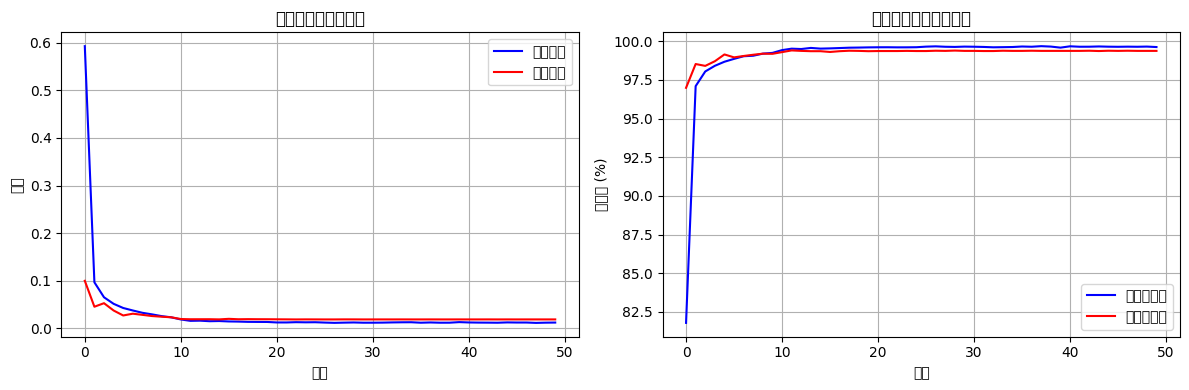

In [48]:
plt.figure(figsize=(12, 4));

# 绘制损失曲线。
plt.subplot(1, 2, 1);

plt.plot(train_losses, label='训练损失', color='blue'); # 绘制训练损失。
plt.plot(test_losses, label='测试损失', color='red'); # 绘制测试损失。

plt.xlabel('轮次');# 设置x轴标签。
plt.ylabel('损失');# 设置y轴标签。

# 设置标题。
plt.title('训练和测试损失变化');

plt.legend();# 显示图例。

plt.grid(True);# 显示网格。

# 绘制准确率曲线。
plt.subplot(1, 2, 2);
# 绘制训练准确率。
plt.plot(train_accuracies, label='训练准确率', color='blue');
# 绘制测试准确率。
plt.plot(test_accuracies, label='测试准确率', color='red');# 绘制测试准确率。

plt.xlabel('轮次');# 设置x轴标签。
plt.ylabel('准确率 (%)');# 设置y轴标签。

# 设置标题。
plt.title('训练和测试准确率变化');

plt.legend();# 显示图例。

plt.grid(True);# 显示网格。

# 调整子图间距。
plt.tight_layout();
# 显示图形。
plt.show();

In [49]:
if isinstance(model, nn.DataParallel):
    torch.save(model.module.state_dict(), 'mnist_cnn_model.pth');
else:
    torch.save(model.state_dict(), 'mnist_cnn_model.pth');

print("模型已保存到 mnist_cnn_model.pth !");

模型已保存到 mnist_cnn_model.pth !


## 测试：

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
/tmp/ipykernel_55/2736714616.py:35: UserWarnin

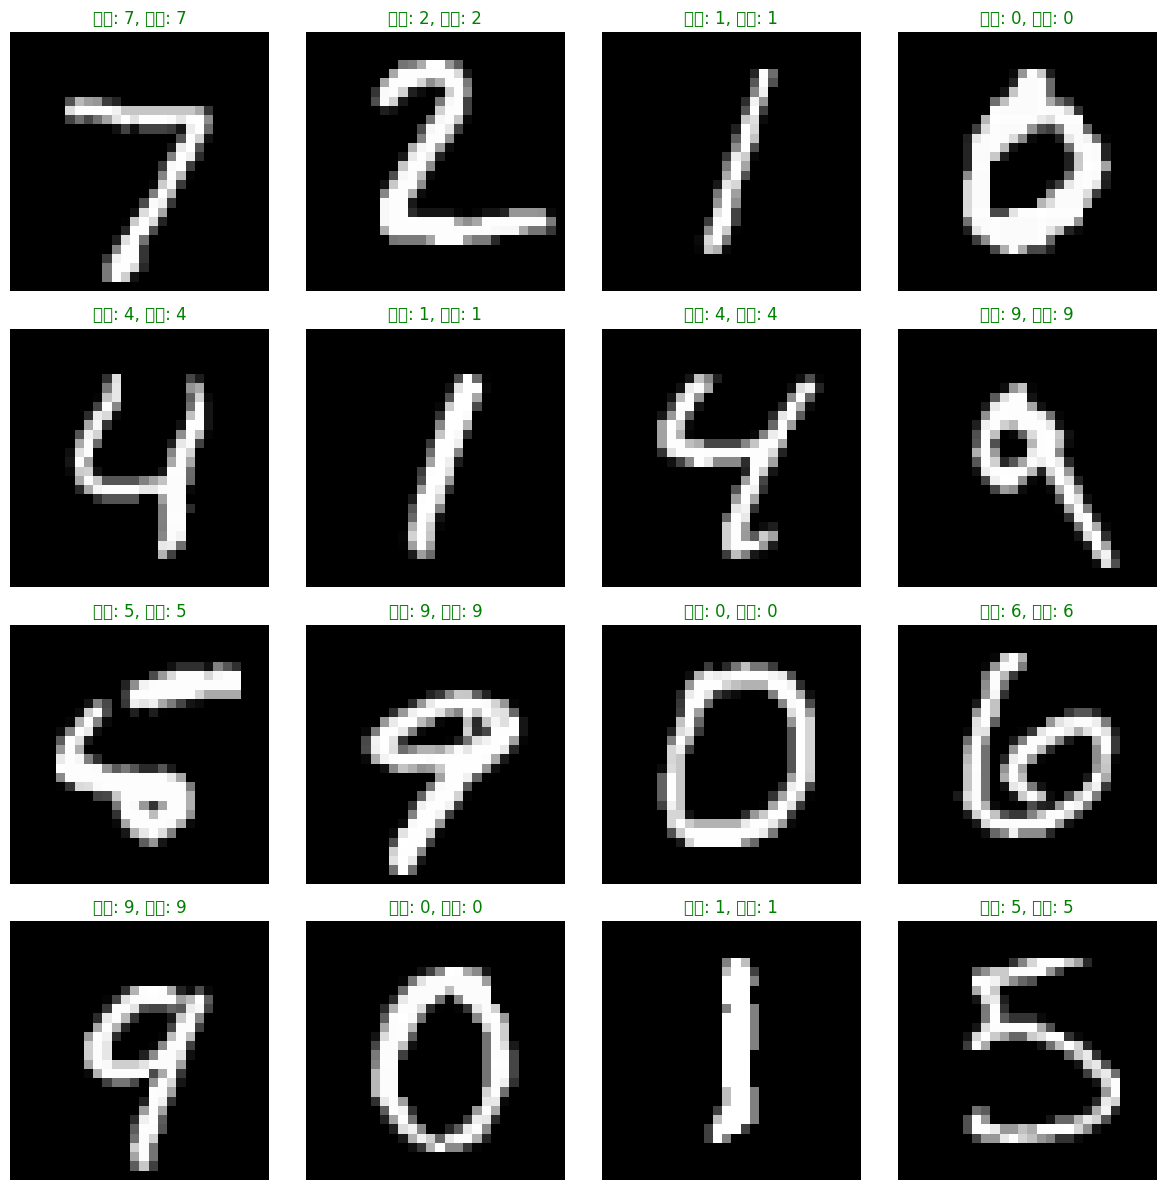

这批样本的准确率: 100.00% ！


In [55]:
def visualize_predictions(model, test_loader, device, num_images=16):
    # 将模型设置为评估模式。
    model.eval();
    # 获取一批测试数据。
    data_iter = iter(test_loader);
    images, labels = next(data_iter);
    
    images = images.to(device);
    
    with torch.no_grad():
        outputs = model(images);
        _, predicted = outputs.max(1);
    
    # 将数据移回CPU以便可视化。
    images = images.cpu();
    predicted = predicted.cpu();
    

    plt.figure(figsize=(12, 12));
    for i in range(num_images):
        plt.subplot(4, 4, i + 1);
        img = images[i].squeeze().numpy();
        plt.imshow(img, cmap='gray');
        
        true_label = labels[i].item();
        pred_label = predicted[i].item();
        
        # 如果预测正确显示绿色，错误显示红色。
        color = 'green' if true_label == pred_label else 'red';

        plt.title(f'真实: {true_label}, 预测: {pred_label}', color=color);

        plt.axis('off');
    
    plt.tight_layout();
    plt.show();
    
    # 计算这批数据的准确率。
    accuracy = (predicted[:num_images] == labels[:num_images]).sum().item() / num_images * 100;
    # 打印准确率。
    print(f"这批样本的准确率: {accuracy:.2f}% ！");


visualize_predictions(model, test_loader, device);

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

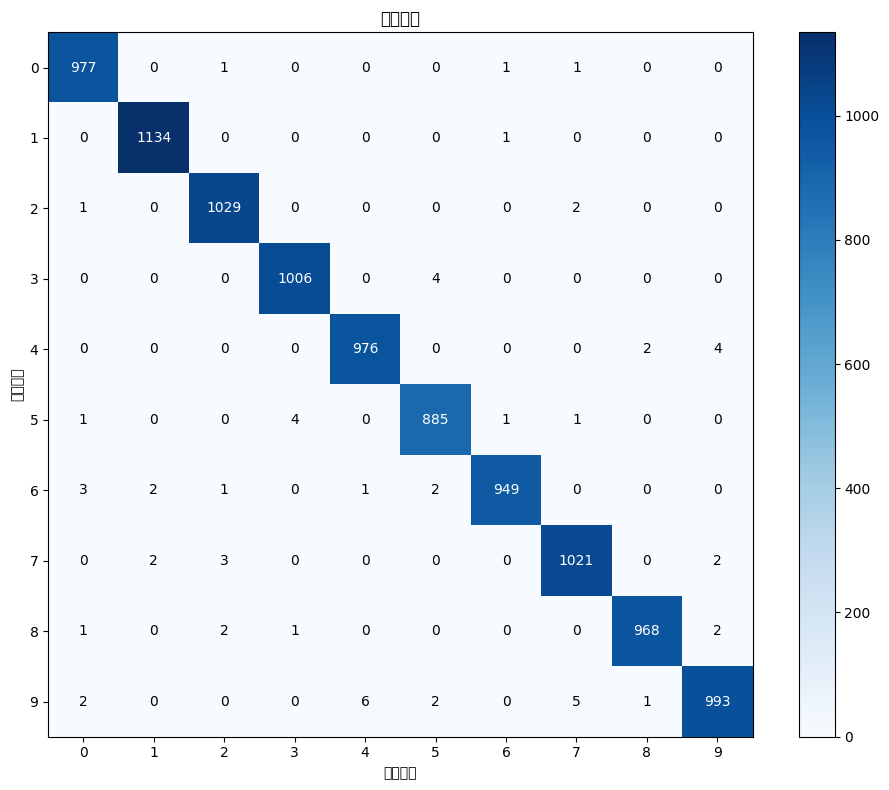

In [52]:
# 计算整个测试集的混淆矩阵。
from sklearn.metrics import confusion_matrix, classification_report;

# 收集所有预测结果和真实标签。
all_preds = [];
all_labels = [];


model.eval();
with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device);

        outputs = model(images);
        _, predicted = outputs.max(1);

        all_preds.extend(predicted.cpu().numpy());
        all_labels.extend(labels.numpy());

# 计算混淆矩阵。
cm = confusion_matrix(all_labels, all_preds);

# 绘制混淆矩阵热力图。
plt.figure(figsize=(10, 8));
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues);
plt.title('混淆矩阵');
plt.colorbar();

# 设置刻度。
tick_marks = np.arange(10);
plt.xticks(tick_marks, range(10));
plt.yticks(tick_marks, range(10));

# 在格子里显示数值。
thresh = cm.max() / 2.0;
for i in range(10):
    for j in range(10):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black");

plt.ylabel('真实标签');
plt.xlabel('预测标签');
plt.tight_layout();
plt.show();

In [53]:
# 打印详细的分类报告。
print("\n分类报告:");
print(classification_report(all_labels, all_preds, target_names=[str(i) for i in range(10)]));


分类报告:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.99      1.00      1.00      1032
           3       1.00      1.00      1.00      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.99      1.00       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [56]:
# 單張圖片預測測試。
def predict_single_image(model, image, device):
    model.eval()
    with torch.no_grad():
        image = image.unsqueeze(0).to(device);
        output = model(image);
        probabilities = torch.softmax(output, dim=1);
        confidence, predicted = torch.max(probabilities, 1);
        return predicted.item(), confidence.item(), probabilities.cpu().numpy()[0];


import random;
test_indices = random.sample(range(len(test_dataset)), 5);# 從測試集隨機選擇5張圖片。

for idx in test_indices:
    img, true_label = test_dataset[idx];
    pred_label, confidence, probs = predict_single_image(model, img, device);
    
    print(f"\n圖片 {idx}:");
    print(f"  真實標籤: {true_label}");
    print(f"  預測標籤: {pred_label}");
    print(f"  置信度: {confidence:.4f}");
    print(f"  預測正確: {'✅' if pred_label == true_label else '✗'}");
    
    top10_indices = np.argsort(probs)[-10:][::-1]
    print(f"  Top-10 預測:");
    for i, class_idx in enumerate(top10_indices):
        print(f"    {i+1}. 數字 {class_idx}: {probs[class_idx]:.4f}");


圖片 8649:
  真實標籤: 8
  預測標籤: 8
  置信度: 1.0000
  預測正確: ✅
  Top-10 預測:
    1. 數字 8: 1.0000
    2. 數字 9: 0.0000
    3. 數字 3: 0.0000
    4. 數字 5: 0.0000
    5. 數字 2: 0.0000
    6. 數字 6: 0.0000
    7. 數字 0: 0.0000
    8. 數字 4: 0.0000
    9. 數字 7: 0.0000
    10. 數字 1: 0.0000

圖片 9388:
  真實標籤: 1
  預測標籤: 1
  置信度: 1.0000
  預測正確: ✅
  Top-10 預測:
    1. 數字 1: 1.0000
    2. 數字 7: 0.0000
    3. 數字 4: 0.0000
    4. 數字 2: 0.0000
    5. 數字 8: 0.0000
    6. 數字 0: 0.0000
    7. 數字 5: 0.0000
    8. 數字 9: 0.0000
    9. 數字 6: 0.0000
    10. 數字 3: 0.0000

圖片 6940:
  真實標籤: 3
  預測標籤: 3
  置信度: 0.9999
  預測正確: ✅
  Top-10 預測:
    1. 數字 3: 0.9999
    2. 數字 5: 0.0001
    3. 數字 2: 0.0000
    4. 數字 9: 0.0000
    5. 數字 7: 0.0000
    6. 數字 1: 0.0000
    7. 數字 8: 0.0000
    8. 數字 6: 0.0000
    9. 數字 4: 0.0000
    10. 數字 0: 0.0000

圖片 7629:
  真實標籤: 4
  預測標籤: 4
  置信度: 1.0000
  預測正確: ✅
  Top-10 預測:
    1. 數字 4: 1.0000
    2. 數字 9: 0.0000
    3. 數字 7: 0.0000
    4. 數字 1: 0.0000
    5. 數字 5: 0.0000
    6. 數字 6: 0.0000
    7. 數字

# ————Ailan Anjuxi